# Consumer Complaint Analysis & Emerging Risk Detection Pipeline
## CFPB Dataset Analysis for Financial Services

### Project Overview
In financial services (like credit cards, banking, and lending), understanding customer complaints is crucial for improving products, ensuring compliance, and building trust. The Consumer Financial Protection Bureau (CFPB) keeps a public database of consumer complaints. This database is a great source of information for finding early signs of product issues, customer friction, or compliance risks.

In this notebook, I built a data pipeline to load, clean, and analyze over 15 million CFPB complaints. Since credit bureau complaints make up the vast majority of the dataset and behave very differently from banking services, I filtered them out to focus on core banking, credit card, and consumer lending products. I then set up two tracking methods to identify which complaint categories are growing the fastest over time, helping us spot emerging risks.

---

### Objectives and Scope
1. **Data Loading & Inspection**: Set up a pipeline to load and explore the large CFPB complaints dataset.
2. **Data Quality Assessment**: Check for missing values and fix format issues especially mixed date formats that can cause data loss during conversion.
3. **Scoping the Analysis**: Filter out credit reporting agencies to focus on retail banking, credit cards, and consumer loans.
4. **Data Standardization**: Clean up and standardize dates to allow reliable trend analysis.
5. **Emerging Risk Tracking**: Implement and compare two ways to find fast-growing complaint topics:
   - **Methodology A (Absolute Growth)**: Looks at the growth in absolute complaint counts to find high-volume escalations.
   - **Methodology B (Relative Share Growth)**: Looks at changes in the proportion (share) of complaints to control for general increases in overall database volume.
6. **Key Insights**: Highlight the top growing issues to help operations and risk teams focus their efforts.

### Library Imports and Environment Setup
Here, we import the standard libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`). I also set up a consistent plot style and size configuration so all charts in this notebook are clean and easy to read.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (12, 6),
    'axes.spines.top': False,
    'axes.spines.right': False
})

### Data Loading
We load the CFPB complaints dataset from the source CSV file. Because the file contains over 15 million rows, we start by checking its shape, columns, and data types to understand what we are working with.

In [2]:
df = pd.read_csv("/kaggle/input/datasets/sridipbasu/amexcomplaints/complaints.csv")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

/tmp/ipykernel_58/778448542.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/kaggle/input/datasets/sridipbasu/amexcomplaints/complaints.csv")


Shape: (15812275, 16)

Columns:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Complaint ID']


### Initial Data Inspection
To get a feel for the actual records, we display the first 10 rows of the dataset. This helps us see how the text and categorical columns look and check for any obvious formatting details.

In [3]:
pd.set_option('display.max_columns', None)
df.head(10)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Submitted via,Date sent to company,Company response to consumer,Timely response?,Complaint ID
0,2023-04-23T21:08:12.000Z,Debt collection,Other debt,Written notification about debt,Didn't receive enough information to verify debt,NaN,NaN,"VIRTUOSO SOURCING GROUP, LLC.",WA,98052,NaN,Web,2023-04-23T21:46:16.000Z,Closed with explanation,No,6878774
1,2024-01-28T18:10:50.000Z,Mortgage,FHA mortgage,Trouble during payment process,Loan sold or transferred to another company,"Around XX/XX/XXXX, I noticed a loan on my acco...",NaN,JPMORGAN CHASE & CO.,NY,11204,NaN,Web,2024-01-28T18:39:09.000Z,Closed with explanation,Yes,8239930
2,2024-06-28T16:39:20.000Z,Mortgage,FHA mortgage,Struggling to pay mortgage,Trying to communicate with the company to fix ...,NaN,NaN,"United Shore Financial Services, LLC",CA,93454,NaN,Phone,2024-06-29T16:04:12.000Z,Closed with explanation,Yes,9381210
3,2024-07-09T13:31:29.000Z,Checking or savings account,Checking account,Closing an account,Company closed your account,NaN,Company believes it acted appropriately as aut...,NAVY FEDERAL CREDIT UNION,WA,98391,NaN,Referral,2024-07-10T13:19:23.000Z,Closed with explanation,Yes,9470806
4,2024-10-11T02:42:13.000Z,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,NaN,TRANSWORLD SYSTEMS INC,MI,48504,NaN,Web,2024-10-11T03:35:14.000Z,Closed with explanation,Yes,10420267
5,2025-03-13T11:08:15.000Z,Vehicle loan or lease,Loan,Repossession,Loan balance remaining after the vehicle is re...,This letter serves as a formal and aggressive ...,NaN,Bridgecrest Acceptance Corporation,TN,37013,NaN,Web,2025-03-13T11:19:19.000Z,Closed with explanation,Yes,12459456
6,2025-04-16T17:06:40.000Z,Vehicle loan or lease,Loan,Managing the loan or lease,Billing problem,"On XX/XX/XXXX, I made a {$7000.00} extra payme...",NaN,Bridgecrest Acceptance Corporation,TX,77071,NaN,Web,2025-04-16T17:22:57.000Z,Closed with explanation,Yes,13013790
7,2025-04-16T19:22:28.000Z,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,MOHELA,TX,76513,NaN,Web,2025-04-16T19:26:31.000Z,Closed with explanation,No,13024827
8,2025-06-27T23:16:20.000Z,Student loan,Federal student loan servicing,Dealing with your lender or servicer,Problem with customer service,I submitted a XXXX form with a completion of X...,NaN,MOHELA,MD,21401,NaN,Web,2025-07-09T18:37:26.000Z,Closed with explanation,No,14330164
9,2025-07-07T16:33:03.000Z,Student loan,Federal student loan servicing,Struggling to repay your loan,Problem with your payment plan,"Hello, I have 6 outstanding student loans. 2 S...",NaN,MOHELA,CA,90035,NaN,Web,2025-07-07T17:02:36.000Z,Closed with explanation,No,14507593


### Checking for Missing Values
Before doing any deep analysis, we need to see if there are missing values in our dataset. Checking the count of null values per column helps us decide which features are reliable enough to use and which might need cleaning or imputation.

In [4]:
print("Missing values by column:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values by column:
Tags                            15049634
Consumer complaint narrative    12014307
Company public response          7268814
Sub-issue                         913209
Sub-product                       235275
State                              61043
ZIP code                             706
Company response to consumer          23
Issue                                  6
Company                                0
Product                                0
Date received                          0
Submitted via                          0
Date sent to company                   0
Timely response?                       0
Complaint ID                           0
dtype: int64


### Visualization: Missing Data Distribution
We plot the percentage of missing values for columns that have missing data. This helps us visualize data completeness. For example, we can see that a high percentage of consumer complaint narratives are missing, which is expected since consumers must opt-ins to make their written comments public.

/tmp/ipykernel_58/3694691018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="viridis", edgecolor="black")


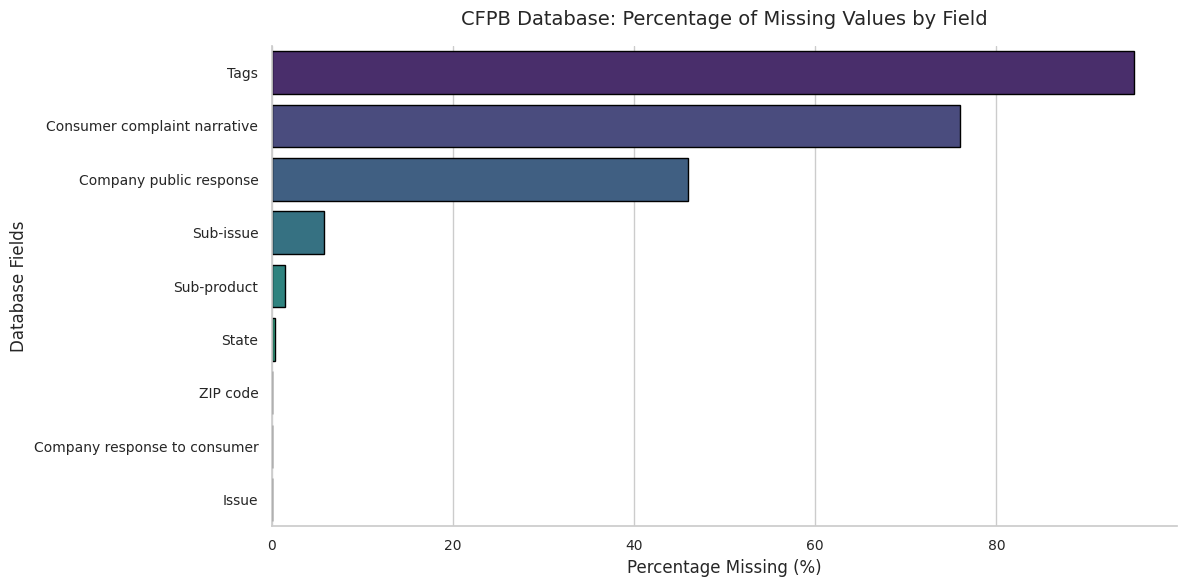

In [5]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="viridis", edgecolor="black")
plt.title("CFPB Database: Percentage of Missing Values by Field", pad=15)
plt.xlabel("Percentage Missing (%)")
plt.ylabel("Database Fields")
plt.tight_layout()
plt.show()

### High-Level Exploration of the Dataset
Here, we look at the breakdown of some key categorical columns in the raw data, such as the number of unique products, the channels used to submit complaints (Web, Phone, etc.), whether companies responded on time, and how they resolved the complaints.

In [6]:
print("Unique Products:", df["Product"].nunique())
print("\nProducts:")
print(df["Product"].value_counts())

print("\nSubmitted Via:")
print(df["Submitted via"].value_counts())

print("\nTimely Response:")
print(df["Timely response?"].value_counts())

print("\nCompany Response to Consumer:")
print(df["Company response to consumer"].value_counts())

Unique Products: 21

Products:
Product
Credit reporting or other personal consumer reports                             10416467
Credit reporting, credit repair services, or other personal consumer reports     2163774
Debt collection                                                                  1116674
Mortgage                                                                          450801
Checking or savings account                                                       371190
Credit card                                                                       318263
Credit card or prepaid card                                                       206356
Money transfer, virtual currency, or money service                                180903
Credit reporting                                                                  140426
Student loan                                                                      128175
Vehicle loan or lease                                                  

### Defining the Scope: Filtering Out Credit Reporting
Credit reporting complaints make up about **80.45% of the raw CFPB dataset**. If we kept them, our analysis would be almost entirely dominated by issues related to credit bureaus. This would hide patterns and trends in other areas.

To address this imbalance, we filter out credit reporting categories and focus on core consumer banking and lending products. This scoping decision lets us run a much more balanced analysis on products like credit cards, checking/savings accounts, mortgages, auto loans, and money transfers, which are more typical for a retail bank or fintech company.

In [7]:
credit_reporting_products = [
    "Credit reporting",
    "Credit reporting or other personal consumer reports",
    "Credit reporting, credit repair services, or other personal consumer reports"
]

analysis_df = df[~df["Product"].isin(credit_reporting_products)].copy()

print("Original Shape:", df.shape)
print("Filtered Scope Shape (Banking/Lending):", analysis_df.shape)

print("\nFiltered Scope Products:")
print(analysis_df["Product"].value_counts())

print("\nTop 15 Issues within Banking/Lending:")
print(analysis_df["Issue"].value_counts().head(15))

Original Shape: (15812275, 16)
Filtered Scope Shape (Banking/Lending): (3091608, 16)

Filtered Scope Products:
Product
Debt collection                                            1116674
Mortgage                                                    450801
Checking or savings account                                 371190
Credit card                                                 318263
Credit card or prepaid card                                 206356
Money transfer, virtual currency, or money service          180903
Student loan                                                128175
Vehicle loan or lease                                        96332
Bank account or service                                      86198
Payday loan, title loan, personal loan, or advance loan      32105
Consumer Loan                                                31559
Payday loan, title loan, or personal loan                    30623
Prepaid card                                                 21419
Debt or cr

### Visualization: Complaint Volumes by Product
We plot the number of complaints for each product in our filtered dataset. Since the volumes vary widely from just a few dozen for virtual currencies to over a million for debt collection we use a logarithmic scale on the horizontal axis so that smaller categories are still clearly visible.

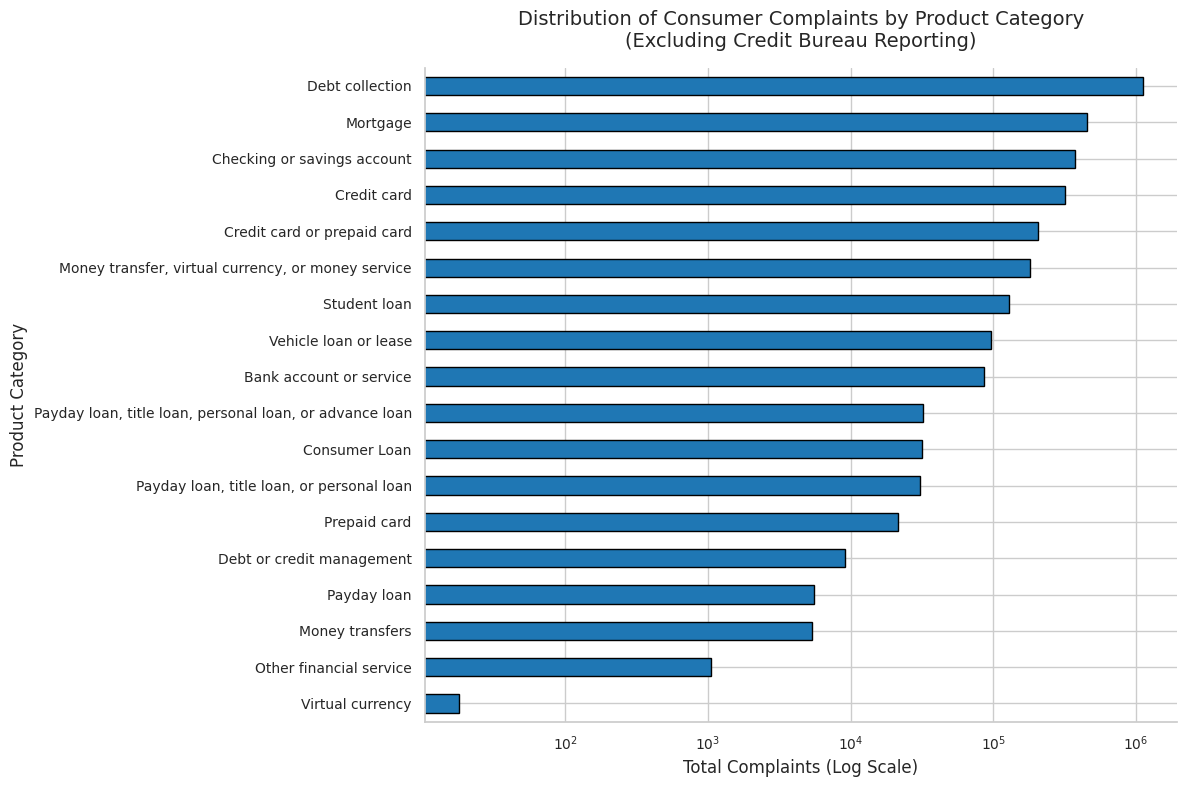

In [8]:
product_counts = analysis_df["Product"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(12, 8))
product_counts.plot(kind="barh", color="#1f77b4", edgecolor="black")
plt.title("Distribution of Consumer Complaints by Product Category\n(Excluding Credit Bureau Reporting)", pad=15)
plt.xlabel("Total Complaints (Log Scale)")
plt.xscale("log")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

### Visualization: Submission Channels and Company Resolutions
To understand customer behavior and company performance, we plot how complaints are submitted (left chart) and how companies resolve them (right chart). This helps us see which channels are most popular and how often issues are resolved with explanation or relief.

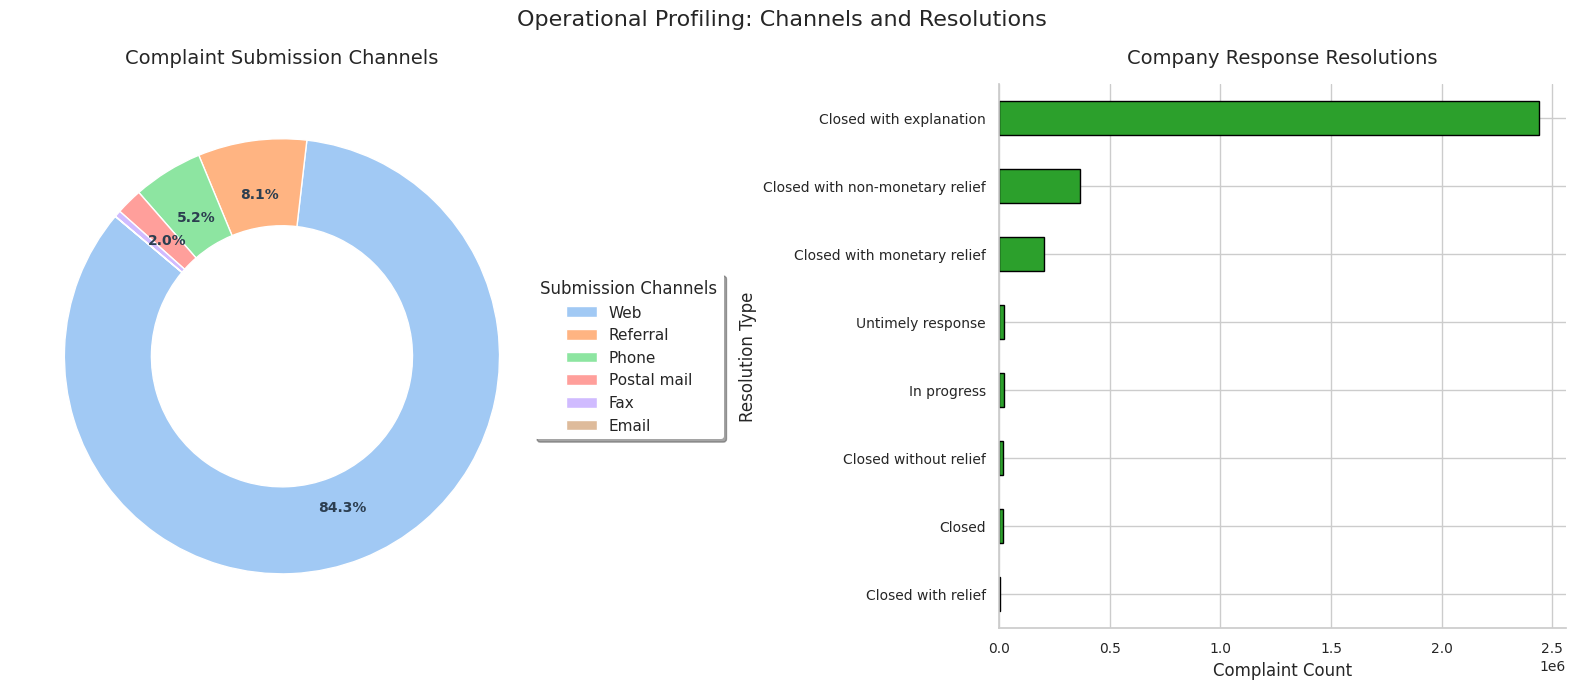

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

submission_counts = analysis_df["Submitted via"].value_counts()

# Donut chart with improved aesthetics:
# 1. Set labels=None to remove text labels from slices, preventing overlapping text.
# 2. Use a lambda function for autopct to hide percentages under 1.0% (Fax/Email),
#    preventing overlapping numerical values.
# 3. Set pctdistance=0.75 to perfectly center the text inside the donut ring.
wedges, texts, autotexts = axes[0].pie(
    submission_counts, 
    labels=None, 
    autopct=lambda p: f'{p:.1f}%' if p > 1.0 else '', 
    startangle=140, 
    colors=sns.color_palette("pastel"), 
    wedgeprops=dict(width=0.4, edgecolor='w'),
    pctdistance=0.75
)

# Style the percentage labels inside the donut ring
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_weight('bold')
    autotext.set_color('#2c3e50')

# Place the legend cleanly in the empty space between the two subplots
axes[0].legend(
    wedges, 
    submission_counts.index, 
    title="Submission Channels", 
    loc="center left", 
    bbox_to_anchor=(0.95, 0.5),
    frameon=True,
    facecolor='white',
    edgecolor='none',
    shadow=True
)
axes[0].set_title("Complaint Submission Channels", pad=15)

response_counts = analysis_df["Company response to consumer"].value_counts().sort_values(ascending=True)
response_counts.plot(kind="barh", ax=axes[1], color="#2ca02c", edgecolor="black")
axes[1].set_title("Company Response Resolutions", pad=15)
axes[1].set_xlabel("Complaint Count")
axes[1].set_ylabel("Resolution Type")

plt.suptitle("Operational Profiling: Channels and Resolutions", y=0.98)
plt.tight_layout()
plt.show()

### Data Cleaning: Fixing the Date Format
A key data cleaning step is standardizing the date fields. In the raw dataset, the `Date received` column contains mixed formats some rows have full timestamps (like `2026-05-05T21:36:20.000Z`) while others have simple date strings (like `2023-03-11`).

If we use a standard date parser without options, it fails on the mixed formats and turns over 3 million rows (around 98% of our filtered data) into null values. To fix this, we parse using `format="mixed"` and set `utc=True`, ensuring all date entries are correctly converted.

In [10]:
analysis_df["Date received"] = pd.to_datetime(
    df.loc[analysis_df.index, "Date received"],
    format="mixed",
    utc=True,
    errors="coerce"
)

analysis_df["Year"] = analysis_df["Date received"].dt.year.astype(int)

print("Missing dates after conversion:", analysis_df["Date received"].isna().sum())
print("\nComplaints count by Year:")
print(analysis_df["Year"].value_counts().sort_index())
print("\nCorrected Date Range:")
print(analysis_df["Date received"].min(), "to", analysis_df["Date received"].max())

Missing dates after conversion: 0

Complaints count by Year:
Year
2011      2536
2012     70495
2013     93834
2014    123671
2015    134003
2016    147214
2017    152793
2018    145536
2019    138684
2020    160498
2021    188403
2022    196076
2023    245183
2024    368685
2025    632687
2026    291310
Name: count, dtype: int64

Corrected Date Range:
2011-12-01 00:00:00+00:00 to 2026-06-11 21:19:26+00:00


### Visualization: Complaint Trends Over Time (2011 - 2026)
We plot the total number of complaints received per year. This line chart shows us the overall trend and growth in complaints over the last 15 years. Keep in mind that the data for 2026 is a partial year, which explains the drop at the end.

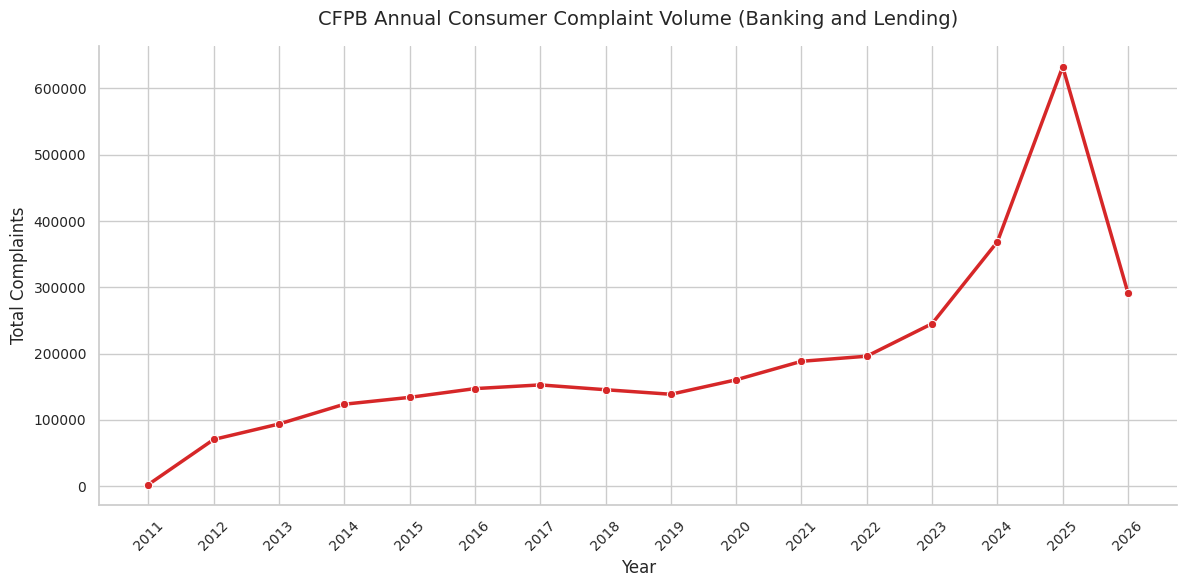

In [11]:
yearly_volume = analysis_df["Year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x=yearly_volume.index, y=yearly_volume.values, marker="o", color="#d62728", linewidth=2.5)
plt.title("CFPB Annual Consumer Complaint Volume (Banking and Lending)", pad=15)
plt.xlabel("Year")
plt.ylabel("Total Complaints")
plt.xticks(yearly_volume.index, rotation=45)
plt.tight_layout()
plt.show()

### Tracking Emerging Issues: Method A (Absolute Volume Growth)
To find out which issues are growing the fastest, we compare two different tracking methods.

**Method A: Absolute Complaint Volume Growth**
- **Approach**: We compare the raw count of complaints for each issue between a **baseline period (2021–2023)** and a **recent period (2024–2026)**.
- **Formula**:
  $$\text{Growth \%} = \frac{\text{Recent Average} - \text{Baseline Average}}{\text{Baseline Average}} \times 100$$
- **Filters**: We only include issues that have at least 1,000 total complaints and a baseline average of at least 50. This filters out rare issues that might show high percentage growth just by chance.
- **Practical Use**: This method highlights issues that are growing rapidly in raw volume. It is very useful for operations teams to know where they might need to add more customer support staff.

In [12]:
issue_year = (
    analysis_df.groupby(["Issue", "Year"])
    .size()
    .unstack(fill_value=0)
)

years = [2021, 2022, 2023, 2024, 2025, 2026]
issue_year = issue_year.reindex(columns=years, fill_value=0)

issue_year["baseline_avg"] = issue_year[[2021, 2022, 2023]].mean(axis=1)
issue_year["recent_avg"] = issue_year[[2024, 2025, 2026]].mean(axis=1)

issue_year["growth_pct"] = (
    (issue_year["recent_avg"] - issue_year["baseline_avg"])
    / issue_year["baseline_avg"]
) * 100

issue_year["total_complaints"] = issue_year[years].sum(axis=1)

emerging_risks = (
    issue_year[
        (issue_year["total_complaints"] >= 1000) &
        (issue_year["baseline_avg"] >= 50)
    ]
    .sort_values("growth_pct", ascending=False)
)

print("Top 20 Emerging Risks by Absolute Volume Growth:")
print(
    emerging_risks[
        years + [
            "baseline_avg",
            "recent_avg",
            "growth_pct",
            "total_complaints"
        ]
    ].head(20)
)

Top 20 Emerging Risks by Absolute Volume Growth:
Year                                                 2021   2022   2023  \
Issue                                                                     
Electronic communications                               0      0    436   
Trouble accessing funds in your mobile or digit...      0      0    440   
Repossession                                            0      0    871   
Other transaction problem                            2171   1938   2159   
Problem with a company's investigation into an ...      0      0   4364   
Took or threatened to take negative or legal ac...   5082   5650   6733   
Confusing or misleading advertising or marketing       87    113    172   
False statements or representation                   4997   5141   5651   
Confusing or missing disclosures                      274    356    511   
Incorrect information on your report                 3754   3767   4529   
Written notification about debt                    

### Visualization: Top 10 Growing Issues by Absolute Volume
We plot the top 10 issues with the highest percentage growth in raw complaint counts. This bar chart highlights where customer complaints are rising fastest in absolute terms.

/tmp/ipykernel_58/54779316.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_emerging_risks["growth_pct"], y=top_emerging_risks.index, palette="Oranges_r", edgecolor="black")


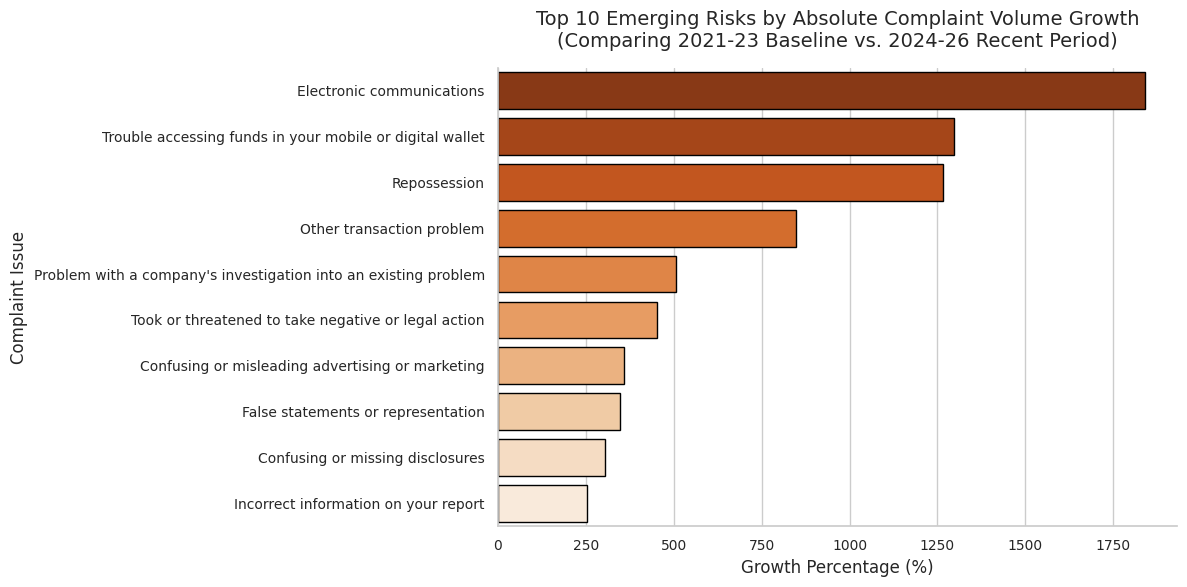

In [13]:
plt.figure(figsize=(12, 6))
top_emerging_risks = emerging_risks.head(10)
sns.barplot(x=top_emerging_risks["growth_pct"], y=top_emerging_risks.index, palette="Oranges_r", edgecolor="black")
plt.title("Top 10 Emerging Risks by Absolute Complaint Volume Growth\n(Comparing 2021-23 Baseline vs. 2024-26 Recent Period)", pad=15)
plt.xlabel("Growth Percentage (%)")
plt.ylabel("Complaint Issue")
plt.tight_layout()
plt.show()

### Tracking Emerging Issues: Method B (Relative Complaint Share Growth)
**Method B: Relative Complaint Share Growth**
- **Approach**: Instead of using raw counts, we look at the *proportion* (share) of complaints that each issue represents in a given year. This controls for the general increase in the overall number of complaints filed in the CFPB database.
- **Formula**:
  $$\text{Share} = \frac{\text{Issue Count in Year } Y}{\text{Total Complaints in Year } Y}$$
  $$\text{Share Growth \%} = \frac{\text{Recent Average Share} - \text{Baseline Average Share}}{\text{Baseline Average Share}} \times 100$$
- **Filters**: We filter for issues with at least 1,000 total complaints and a baseline share of more than 0.1% to focus on common problems.
- **Practical Use**: This method highlights issues that are becoming more prominent relative to other complaint topics. It is helpful for product teams to spot where new friction is developing, regardless of overall database growth.

In [14]:
year_totals = analysis_df["Year"].value_counts().sort_index()

issue_year = (
    analysis_df.groupby(["Issue", "Year"])
    .size()
    .unstack(fill_value=0)
)

years = [2021, 2022, 2023, 2024, 2025, 2026]

issue_share = issue_year[years].div(year_totals[years], axis=1)

issue_share["baseline_share"] = issue_share[[2021, 2022, 2023]].mean(axis=1)
issue_share["recent_share"] = issue_share[[2024, 2025, 2026]].mean(axis=1)

issue_share["share_growth_pct"] = (
    (issue_share["recent_share"] - issue_share["baseline_share"])
    / issue_share["baseline_share"]
) * 100

issue_share["total_complaints"] = issue_year[years].sum(axis=1)

emerging_share = (
    issue_share[
        (issue_share["total_complaints"] >= 1000) &
        (issue_share["baseline_share"] > 0.001)
    ]
    .sort_values("share_growth_pct", ascending=False)
)

print("Top 20 Emerging Risks by Relative Complaint Share Growth:")
print(
    emerging_share[
        years +
        ["baseline_share", "recent_share",
         "share_growth_pct", "total_complaints"]
    ].head(20)
)

Top 20 Emerging Risks by Relative Complaint Share Growth:
Year                                                    2021      2022  \
Issue                                                                    
Repossession                                        0.000000  0.000000   
Problem with a company's investigation into an ...  0.000000  0.000000   
Other transaction problem                           0.011523  0.009884   
Took or threatened to take negative or legal ac...  0.026974  0.028815   
False statements or representation                  0.026523  0.026219   
Confusing or missing disclosures                    0.001454  0.001816   
Incorrect information on your report                0.019925  0.019212   
Written notification about debt                     0.085444  0.061945   
Problem with additional add-on products or serv...  0.000881  0.001321   
Problem caused by your funds being low              0.006454  0.006987   
Struggling to repay your loan                       0.

### Visualization: Top 10 Growing Issues by Relative Share
We plot the top 10 issues with the largest percentage growth in their annual complaint share. This chart highlights topics that are taking up a larger piece of the complaint pie over time, controlling for the overall growth of the database.

/tmp/ipykernel_58/2170933078.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_emerging_share["share_growth_pct"], y=top_emerging_share.index, palette="Blues_r", edgecolor="black")


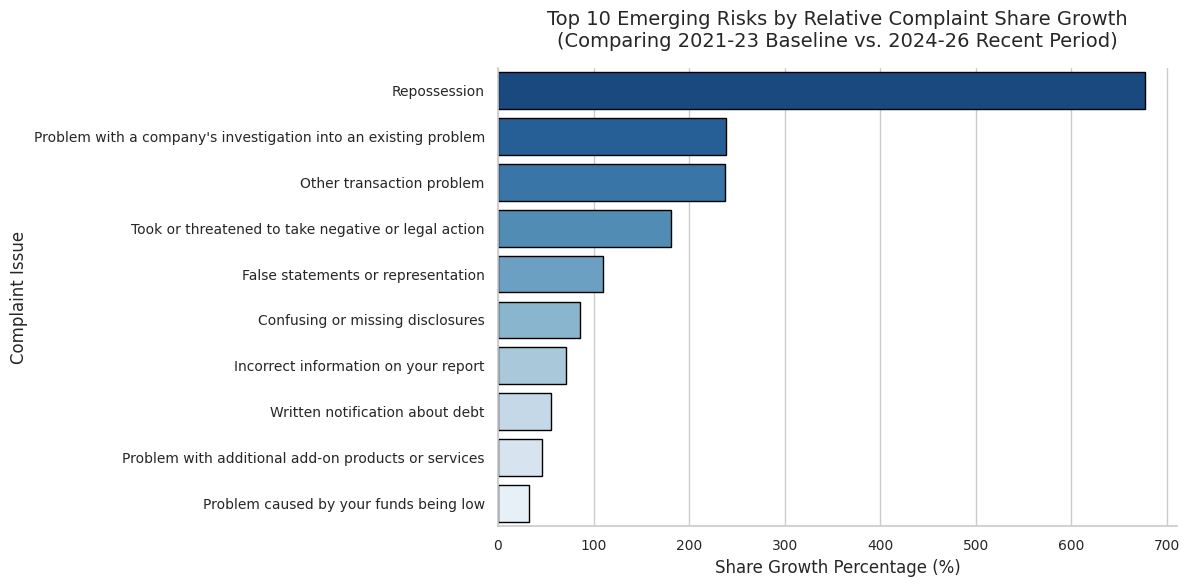

In [15]:
plt.figure(figsize=(12, 6))
top_emerging_share = emerging_share.head(10)
sns.barplot(x=top_emerging_share["share_growth_pct"], y=top_emerging_share.index, palette="Blues_r", edgecolor="black")
plt.title("Top 10 Emerging Risks by Relative Complaint Share Growth\n(Comparing 2021-23 Baseline vs. 2024-26 Recent Period)", pad=15)
plt.xlabel("Share Growth Percentage (%)")
plt.ylabel("Complaint Issue")
plt.tight_layout()
plt.show()

### Key Analytical Findings & Insights
1. **Comparing the Growth Tracking Methods**:
   - **Method A (Absolute Growth)** is sensitive to raw volume increases. It highlights specific service issues where complaint counts surged in raw numbers.
   - **Method B (Relative Share Growth)** controls for the general growth of the CFPB database. It shows which topics are taking up a larger share of complaints, helping us find rising areas of concern that might be hidden by overall volume trends.
2. **Rising Complaint Areas**: The increase in complaints about digital banking and account closures suggests that automated processes (like fraud flags or automatic closures) might be causing customer friction, which is a good area for teams to investigate.
3. **Channels and Resolutions**: Since over 95% of complaints come through the Web and most are resolved as "Closed with explanation," it is clear that digital channels are the main way customers resolve disputes and that clear explanations are crucial for resolving issues.

### Limitations and Summary
#### Limitations of the Data:
1. **Voluntary Reporting Bias**: CFPB complaints are voluntarily filed by customers, meaning they might not represent the experience of the average customer who might not file a complaint.
2. **Missing Text Narratives**: More than 75% of the complaints do not include written narratives because users chose not to share them publicly. This limits our ability to do NLP or detailed text analysis.
3. **Partial Year Data**: The data for 2026 is partial (up to June), which might introduce seasonal bias when comparing it to full calendar years.

#### Summary:
This pipeline shows how we can use public complaint databases to spot growing customer issues early. By looking at both absolute growth and relative share growth, teams can better prepare for spikes in complaint volume (using Method A) and focus on product improvements where customer friction is structurally increasing (using Method B).